# RAPID-MFA-2: The stock driven model

## Descriptions
This is the basic RAPID MFA stock driven model. It takes two inputs:
- A _stocks_ time series (of materials, products, service units, etc.)
- A _survival curve_ describing the survival/depreciation of inflow cohorts in the stocks as time goes by.

It produces two main model outputs:
- The _inflows_ time series
- The _outflows_ time series

And two auxiliary model outputs:
- The _cohorts survival matrix_ table
- The _stock changes_ (net addition to stock) time series

using the stock driven model equations:
$$
\begin{align}
\textcolor{#20B2AA}{\text{inflows}(t)} &= \frac{\textcolor{#DC322F}{\text{stocks}(t)} - \sum_{c=t_0}^{t-1} [\textcolor{#20B2AA}{\text{inflows}(c)} \times \textcolor{#9370DB}{\text{survival\_curve}(t-c)}]}{\textcolor{#9370DB}{\text{survival\_curve}(0)}}
\\
\textcolor{#8E795E}{\text{stock\_changes}(t)} &= \textcolor{#DC322F}{\text{stocks}(t)} - \textcolor{#DC322F}{\text{stocks}(t-1)}
\\
\textcolor{#D19F37}{\text{outflows}(t)} &= \textcolor{#2A8596}{\text{inflows}(t)} - \textcolor{#8E795E}{\text{stock\_changes}(t)}
\end{align}
$$

### The exogenous input variables used in this example
__Stocks:__ mock stocks values for years 1950-2019, in kg.

__Survival curve:__ mock values. Normal distribution, $mean=30$, $SD=8.5$, chosen to exemplify that the model works even in a case in which survival in year 0 is not 100%, i.e. there is already some outflow (throughput) from each inflow in its year of occurance.

### Notes
1. The input data is intended to be replaced with your own data, for example imported from an Excel or CSV file. It should be in an array-like format of any length.
2. The model is split into separate code blocks for ease of understanding. The code blocks can be merged to run as a complete model.

### Relations with other RAPID-MFA notebooks
This code is the core building block for all other RAPID-MFA notebooks that use the stock driven model. Most don't modify this core code, except these two variants:
- `RAPID-MFA-1: The flow driven model`: the __survival curve__ is identical, and this code's _input_ __stocks__ data are identical to the model _output_ __stocks__ calculated in `RAPID-MFA-1: The flow driven model` to show that the flow-driven model and stock-driven model are the reverse operations of each other. The resulting MFA system of both notebooks has the same values (ignoring computational imprecision from roundoff errors).

- `RAPID-MFA-4: The stock driven model with outflow generation curves` replaces the _survival curve_ with the _outflow generation curve_ for use when the outflows composition is required. 

### Version, licence, and how to cite

Version 2026.7 - check the [RAPID MFA GitHub repository](https://github.com/TomerFishman/RAPID-MFA/) for changes, history, and updates.

This code was created and is maintained by the [RAPID MFA development team](https://github.com/TomerFishman/RAPID-MFA/tree/master#contributors-and-acknowledgements).

This notebook is <a href="https://creativecommons.org/licenses/by-nc/4.0"><img src="https://mirrors.creativecommons.org/presskit/buttons/88x31/png/by-nc.png" alt="CC-BY-NC" width="70"> CC-BY-NC</a>, meaning you can - and should! - freely reuse and adapt this code for noncommercial purposes __as long as you attribute this source__. 


## 1. Load libraries

In [11]:
# %% 1. Load libraries
import numpy as np
import pandas as pd
import scipy.stats
import seaborn as sns

## 2. Define example input data

In [12]:
# %% 2. Define example input data

# stocks data
input_data = pd.Series([1299.6975823,       2699.2088439999998, 3898.5122223,       4897.5146912,
                        5596.1111347999995, 7593.7676341999995, 9790.3254385,       12085.3702772,
                        14878.236956,       17868.1931554,      19254.6465997,      20536.1767666, 
                        22511.102249000003, 24677.600006200002, 27633.2189704,      29075.6457275, 
                        32001.0827125,      35205.8857545,      37885.8588263,      40636.0181198, 
                        41951.2947246,      44425.3763232,      47152.122083999995, 50024.97634079999, 
                        52937.21044549999,  55882.04176919999,  58952.77810709999,  61643.12697669999, 
                        64746.97994249999,  67859.00552129999,  70274.67869049999,  73289.90071599999, 
                        76601.6953655,      80407.8897283,      84207.3297966,      87999.6228713, 
                        91885.10090430001,  96064.68824460001,  100539.808329,      104712.3261015, 
                        108784.1202204,     112757.07243968,    116832.8291535,     122312.42061113, 
                        125997.28886605,    129087.59914197,    132282.91175889,    135482.23008601, 
                        138683.84854315,    141885.3850872,     145183.804137639,   148775.47728947402, 
                        152056.47224253102, 155322.363692951,   158968.47456797402, 161990.35422655602, 
                        164983.39759476003, 167943.37824593892, 171066.4844396428,  174749.45930044842, 
                        176390.45907074612, 177987.76127631642, 179540.96353597206, 180950.77883671026, 
                        182418.98656639198, 185248.20469443387, 186242.99278443994, 186608.17355946472, 
                        187049.45240187363, 188373.1468656902], 
                       name = 'stocks', 
                       index = [1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 
                                1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 
                                1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 
                                1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 
                                1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 
                                2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 
                                2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019])  # mock values

# Parameters for the survival curve
ages = range(0, len(input_data))  # the maximum age in the MFA model is equal to the length of the input data
mean = 30
std_dev = 8.5

# create the survival curve
survival_curve = scipy.stats.norm.sf(ages, loc=mean, scale=std_dev)

## 3. Set up the MFA system

In [13]:
# %% 3. Set up the MFA system
units = {'time_interval':   'year', 
         'flows':           'kg/year', 
         'stocks':          'kg'}

timeframes = cohorts = input_data.index  # timeframes are the "snapshots" of the system in every time interval, while cohorts are the inflows that enter the system in every time interval. They are the same because we have one inflow per time interval.

time_interval = 1 # Interval between timeframes, often 1 year or 1 month etc.

cohort_stop = (cohorts[-1] + time_interval)  # because of exclusive slicing in python, an extra time interval is required


mfa_system = pd.DataFrame(index=timeframes, columns = ['stocks', 
                                                         'inflows', 
                                                         'outflows', 
                                                         'stock_changes'])

mfa_system['stocks'] = input_data
mfa_system['stocks']

1950      1299.697582
1951      2699.208844
1952      3898.512222
1953      4897.514691
1954      5596.111135
            ...      
2015    185248.204694
2016    186242.992784
2017    186608.173559
2018    187049.452402
2019    188373.146866
Name: stocks, Length: 70, dtype: float64

## 4. Create the survival curves matrix

In this basic example, all inflow cohorts follow the same survival curve so the survival curve is shifted down the diagonal of the matrix, i.e. a [Toeplitz matrix](https://en.wikipedia.org/wiki/Toeplitz_matrix). check the [RAPID MFA GitHub repository](https://github.com/TomerFishman/RAPID-MFA/) for examples in which cohorts have differing survival curves, such as lifetime extension.

In [14]:
# %% 4. Create survival curves matrix
# create survival curves matrix filled with zeros
survival_curves_matrix = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)

# and populate that matrix
for cohort in cohorts:
    # at each iteration, shift the survival curve and fill the next column of the survival curves matrix with the shifted survival curve from the diagonal downwards.
    survival_curves_matrix.loc[cohort: , cohort] = survival_curve[0 : cohort_stop - cohort]
   
survival_curves_matrix

,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,...,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019
1950,0.999792,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1951,0.999677,0.999792,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1952,0.999506,0.999677,0.999792,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1953,0.999255,0.999506,0.999677,0.999792,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1954,0.998889,0.999255,0.999506,0.999677,0.999792,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015,0.000019,0.000032,0.000052,0.000083,0.000133,0.000208,0.000323,0.000494,0.000745,0.001111,...,0.998365,0.998889,0.999255,0.999506,0.999677,0.999792,0.000000,0.000000,0.000000,0.000000
2016,0.000011,0.000019,0.000032,0.000052,0.000083,0.000133,0.000208,0.000323,0.000494,0.000745,...,0.997625,0.998365,0.998889,0.999255,0.999506,0.999677,0.999792,0.000000,0.000000,0.000000
2017,0.000007,0.000011,0.000019,0.000032,0.000052,0.000083,0.000133,0.000208,0.000323,0.000494,...,0.996594,0.997625,0.998365,0.998889,0.999255,0.999506,0.999677,0.999792,0.000000,0.000000
2018,0.000004,0.000007,0.000011,0.000019,0.000032,0.000052,0.000083,0.000133,0.000208,0.000323,...,0.995177,0.996594,0.997625,0.998365,0.998889,0.999255,0.999506,0.999677,0.999792,0.000000


## 5. Create cohorts survival matrix and calculate the inflows

Each column of the cohorts' survival matrix describes the decline of an inflow cohort as time goes by.

Each row of the cohorts' survival matrix describes the amount still in the stock of each past and present inflow cohort, i.e. the composition of the stocks.

In the stock-driven model, each column of this matrix is created iteratively with the inflow calculated with the following equation, and using the inflows calculated in the previous iterations:

$$
\textcolor{#20B2AA}{\text{inflow}(t)} = \frac{\textcolor{#DC322F}{\text{stock}(t)} - \sum_{c=t_0}^{t-1} [\textcolor{#20B2AA}{\text{inflow}(c)} \times \textcolor{#9370DB}{\text{survival\_curve}(t-c)}]}{\textcolor{#9370DB}{\text{survival\_curve}(0)}}
$$

The denominator $\text{survival\_curve}(0)$ deals with any throughput of inflows that become outflows in the same year. In survival curves like the Weibull in which the $\text{survival\_curve}(0) = 1$, there are no throughputs.


<Axes: >

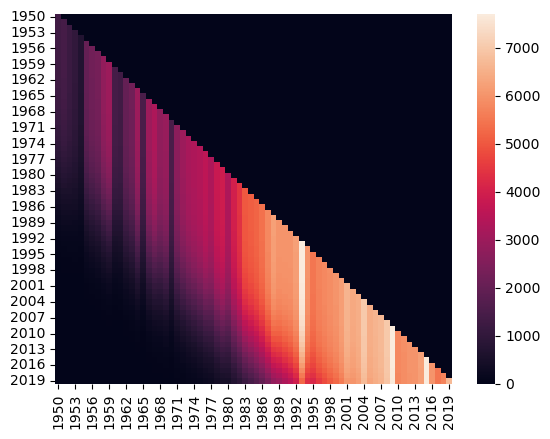

In [15]:
# %% 5. Create cohorts survival matrix and calculate the inflows

# initialize the cohort_survival_matrix filled with zeros
cohorts_survival_matrix = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)

# And populate it
for cohort in cohorts:
    # calculate the inflow of the time-th year
    mfa_system.loc[cohort, 'inflows'] = (
        mfa_system.loc[cohort, 'stocks'] - cohorts_survival_matrix.loc[cohort, : cohort - 1].sum()
    ) / survival_curves_matrix.loc[cohort, cohort]
    # now that the time-th inflow is known, scale the shifted survival curve with this inflow
    cohorts_survival_matrix.loc[:, cohort] = survival_curves_matrix.loc[:, cohort] * mfa_system.loc[cohort, 'inflows']
    
# and visualize the cohort_survival_matrix matrix with a heatmap
sns.heatmap(cohorts_survival_matrix, annot=False)

## 6. Calculate the MFA system
### 6.1 Calculate stock changes
$$\textcolor{#8E795E}{\text{stock\_changes}(t)} = \textcolor{#DC322F}{\text{stocks}(t)} - \textcolor{#DC322F}{\text{stocks}(t-1)}$$
prepend=0 replicates the convention that stock_change is the difference between current timeframe and previous timeframe. 

In [16]:
# %% 6. Calculate the MFA system
# %%% 6.1 calculate stock changes (net change to stock)
# stock_changes is the difference between two timeframes.
# prepend=0 replicates the convention that stock_change is the difference between current timeframe and previous timeframe. 
mfa_system["stock_changes"] = np.diff(mfa_system["stocks"], prepend=0)
mfa_system["stock_changes"]

1950    1299.697582
1951    1399.511262
1952    1199.303378
1953     999.002469
1954     698.596444
           ...     
2015    2829.218128
2016     994.788090
2017     365.180775
2018     441.278842
2019    1323.694464
Name: stock_changes, Length: 70, dtype: float64

### 6.2 Calculate outflows
using mass balance
$$\textcolor{#D19F37}{\text{outflows}(t)} = \textcolor{#2A8596}{\text{inflows}(t)} - \textcolor{#8E795E}{\text{stock\_changes}(t)}$$

In [17]:
# %%% 6.2 Calculate outflows
# using mass balance
mfa_system["outflows"] = mfa_system["inflows"] - mfa_system["stock_changes"]
mfa_system["outflows"]

1950       0.270708
1951       0.440345
1952       0.632352
1953       0.912145
1954       1.293076
           ...     
2015    4871.299951
2016    5006.400993
2017    5136.565778
2018    5260.897208
2019    5378.763058
Name: outflows, Length: 70, dtype: object

## 7. View the full MFA system

<Axes: ylabel='kg/year'>

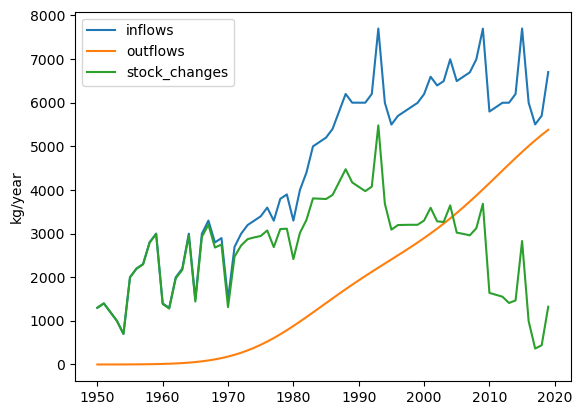

In [18]:
# %% 7. View the full MFA system
# plot flows
mfa_system[["inflows", "outflows", "stock_changes"]].plot(ylabel=units['flows'])

<Axes: ylabel='kg'>

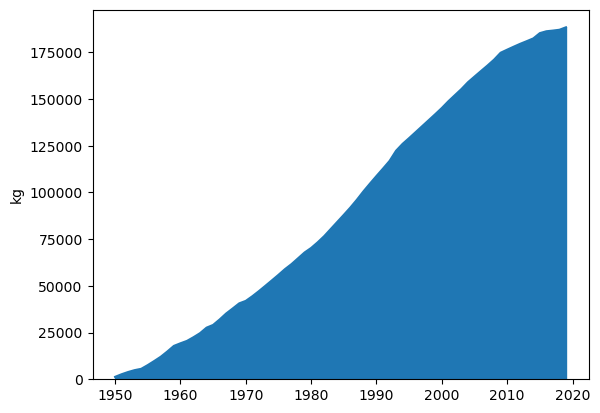

In [19]:
# plot stocks
mfa_system["stocks"].plot(kind="area", stacked=True, ylabel=units['stocks'])

<Axes: ylabel='kg'>

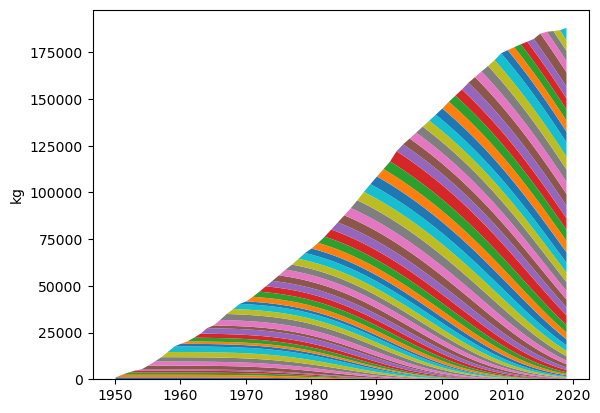

In [20]:
# plot stocks composition by cohorts
cohorts_survival_matrix.plot(kind="area", stacked=True, legend = False, lw=0, ylabel=units['stocks'])